In [11]:
import math
from collections import Counter
def encode(data):
    data = [row[:] for row in data]
    for j in range(len(data[0])):
        values = [row[j] for row in data if row[j] is not None]
        if not all(isinstance(x, (int, float)) for x in values):
            unique = list(dict.fromkeys(values))
            mapping = {v: i for i, v in enumerate(unique)}
            for row in data:
                if row[j] is not None:
                    row[j] = mapping[row[j]]
    return data
def impute(data, method):
    data = [row[:] for row in data]
    for j in range(len(data[0])):
        values = [row[j] for row in data if row[j] is not None]
        if method == "mean":
            value = sum(values) / len(values)
        elif method == "median":
            s = sorted(values)
            n = len(s)
            value = s[n // 2] if n % 2 else (s[n // 2 - 1] + s[n // 2]) / 2
        elif method == "mode":
            value = Counter(values).most_common(1)[0][0]
        else:
            raise ValueError("Invalid imputation method")
        for row in data:
            if row[j] is None:
                row[j] = value
    return data
def distance(x1, x2, metric):
    if metric == "euclidean":
        return math.sqrt(sum((a - b) ** 2 for a, b in zip(x1, x2)))
    elif metric == "manhattan":
        return sum(abs(a - b) for a, b in zip(x1, x2))
    raise ValueError("Invalid distance metric")
def bubble_sort(data):
    data = data[:]
    for i in range(len(data)):
        for j in range(len(data) - i - 1):
            if data[j][0] > data[j + 1][0]:
                data[j], data[j + 1] = data[j + 1], data[j]
    return data
def selection_sort(data):
    data = data[:]
    for i in range(len(data)):
        m = i
        for j in range(i + 1, len(data)):
            if data[j][0] < data[m][0]:
                m = j
        data[i], data[m] = data[m], data[i]
    return data
def insertion_sort(data):
    data = data[:]
    for i in range(1, len(data)):
        key = data[i]
        j = i - 1
        while j >= 0 and data[j][0] > key[0]:
            data[j + 1] = data[j]
            j -= 1
        data[j + 1] = key
    return data
def sort(data, algorithm):
    if algorithm == "bubble":
        return bubble_sort(data)
    elif algorithm == "selection":
        return selection_sort(data)
    elif algorithm == "insertion":
        return insertion_sort(data)
    raise ValueError("Invalid sorting algorithm")
def knn(X_train, y_train, X_test, config):
    X_train = encode(X_train)
    X_train = impute(X_train, config["imputation"])
    distances = []
    for x, y in zip(X_train, y_train):
        distances.append((
            distance(x, X_test, config["distance_metric"]),
            y
        ))
    neighbors = sort(
        distances,
        config["sorting_algorithm"]
    )[:config["k"]]
    votes = Counter(label for d, label in neighbors)
    max_votes = max(votes.values())
    candidates = [
        label for label, count in votes.items()
        if count == max_votes
    ]
    prediction = next(
        label for d, label in neighbors
        if label in candidates
    )
    return prediction, neighbors
X_train = [
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
    [8, 6]
]
y_train = ["A", "A", "A", "B", "B", "B"]

X_test = [5, 5]

CONFIG = {
    "k": 3,
    "imputation": "mean",
    "distance_metric": "euclidean",
    "sorting_algorithm": "bubble"
}
prediction, neighbors = knn(
    X_train,
    y_train,
    X_test,
    CONFIG
)
print("Configuration:")
print(CONFIG)
print("\nNearest Neighbors:")
for d, label in neighbors:
    print("Distance:", round(d, 4), "Class:", label)
print("\nPredicted Class:", prediction)

Configuration:
{'k': 3, 'imputation': 'mean', 'distance_metric': 'euclidean', 'sorting_algorithm': 'bubble'}

Nearest Neighbors:
Distance: 1.0 Class: B
Distance: 2.8284 Class: A
Distance: 2.8284 Class: B

Predicted Class: B


In [7]:
from collections import Counter
def assign_class_weighted(neighbors):
    class_weights = {}
    for distance, label in neighbors:
        weight = 1 / distance if distance != 0 else float("inf")
        class_weights[label] = class_weights.get(label, 0) + weight
    max_weight = max(class_weights.values())
    candidates = [
        label for label, weight in class_weights.items()
        if weight == max_weight
    ]
    if len(candidates) == 1:
        return candidates[0]
    for distance, label in neighbors:
        if label in candidates:
            return label
def weighted_knn_classifier(
    X_train,
    y_train,
    X_test,
    k,
    distance_metric="euclidean",
    sorting_algorithm="bubble"
):
    distances = []
    for i in range(len(X_train)):
        distance = calculate_distance(
            X_train[i],
            X_test,
            distance_metric
        )
        distances.append((distance, y_train[i]))
    neighbors = identify_neighbors(
        distances,
        k,
        sorting_algorithm
    )
    prediction = assign_class_weighted(neighbors)
    return prediction, neighbors
X_train = [
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
    [8, 6]
]
y_train = [
    "A",
    "A",
    "A",
    "B",
    "B",
    "B"
]
X_test = [5, 5]
CONFIG = {
    "k": 3,
    "distance_metric": "euclidean",
    "sorting_algorithm": "bubble"
}
prediction, neighbors = weighted_knn_classifier(
    X_train,
    y_train,
    X_test,
    CONFIG["k"],
    CONFIG["distance_metric"],
    CONFIG["sorting_algorithm"]
)
print("Configuration:")
print(CONFIG)
print("\nNearest Neighbors:")
for distance, label in neighbors:
    weight = 1 / distance if distance != 0 else float("inf")
    print(
        "Distance:", round(distance, 4),
        "Weight:", round(weight, 4),
        "Class:", label
    )
print("\nPredicted Class:", prediction)

Configuration:
{'k': 3, 'distance_metric': 'euclidean', 'sorting_algorithm': 'bubble'}

Nearest Neighbors:
Distance: 1.0 Weight: 1.0 Class: B
Distance: 2.8284 Weight: 0.3536 Class: A
Distance: 2.8284 Weight: 0.3536 Class: B

Predicted Class: B


In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [4, 4],
    [6, 5],
    [7, 7],
    [8, 6],
    [9, 8],
    [5, 6],
    [2, 1]
])
y = np.array([
    "A", "A", "A", "A", "B",
    "B", "B", "B", "A", "A"
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("X_train:")
print(X_train)
print("\ny_train:")
print(y_train)
print("\nX_test:")
print(X_test)
print("\ny_test:")
print(y_test)

X_train:
[[1 2]
 [9 8]
 [3 3]
 [2 1]
 [6 5]
 [4 4]
 [8 6]]

y_train:
['A' 'B' 'A' 'A' 'B' 'A' 'B']

X_test:
[[5 6]
 [2 3]
 [7 7]]

y_test:
['A' 'A' 'B']


In [20]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
print("Predicted Classes:")
print(y_pred)
print("\nActual Classes:")
print(y_test)
print("\nAccuracy:", (y_pred == y_test).mean() * 100, "%")

Predicted Classes:
['B' 'A' 'B']

Actual Classes:
['A' 'A' 'B']

Accuracy: 66.66666666666666 %


In [22]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)
print("Accuracy:", neigh.score(X_test, y_test))

Accuracy: 0.6666666666666666


In [25]:
y_pred = neigh.predict(X_test)
print("Predicted Classes:")
print(y_pred)

Predicted Classes:
['B' 'A' 'B']


In [27]:
import math
from collections import Counter
class MyKNN:
    def __init__(self, k=3, imputation="mean",
                 distance_metric="euclidean",
                 sorting_algorithm="bubble"):
        self.k = k
        self.imputation = imputation
        self.distance_metric = distance_metric
        self.sorting_algorithm = sorting_algorithm
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        return self
    def predict(self, X_test):
        predictions = []
        for test in X_test:
            distances = []
            for i in range(len(self.X_train)):
                d = calculate_distance(
                    self.X_train[i],
                    test,
                    self.distance_metric
                )
                distances.append((d, self.y_train[i]))
            neighbors = identify_neighbors(
                distances,
                self.k,
                self.sorting_algorithm
            )
            votes = Counter(label for d, label in neighbors)
            max_votes = max(votes.values())
            candidates = [
                label for label, count in votes.items()
                if count == max_votes
            ]
            prediction = next(
                label for d, label in neighbors
                if label in candidates
            )
            predictions.append(prediction)
        return predictions
    def score(self, X_test, y_test):
        predictions = self.predict(X_test)
        correct = sum(
            p == actual
            for p, actual in zip(predictions, y_test)
        )
        return correct / len(y_test)

In [31]:
knn = MyKNN(
    k=3,
    imputation="mean",
    distance_metric="euclidean",
    sorting_algorithm="bubble"
)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)
print("Predicted Classes:")
print(predictions)
print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Predicted Classes:
['B', 'A', 'B']

Accuracy: 0.6666666666666666
Accuracy (%): 66.66666666666666


k values: [1, 2, 3, 4, 5]
My kNN accuracy: [0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666]
Scikit-learn accuracy: [0.6666666666666666, 1.0, 0.6666666666666666, 1.0, 0.6666666666666666]


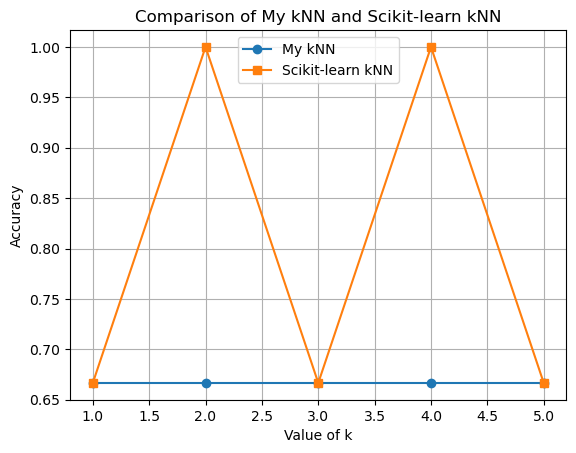

In [33]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
k_values = [1, 2, 3, 4, 5]
my_accuracy = []
sk_accuracy = []
for k in k_values:
    my_knn = MyKNN(
        k=k,
        imputation="mean",
        distance_metric="euclidean",
        sorting_algorithm="bubble"
    )
    my_knn.fit(X_train, y_train)
    my_accuracy.append(my_knn.score(X_test, y_test))

    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train, y_train)
    sk_accuracy.append(sk_knn.score(X_test, y_test))
print("k values:", k_values)
print("My kNN accuracy:", my_accuracy)
print("Scikit-learn accuracy:", sk_accuracy)
plt.plot(k_values, my_accuracy, marker="o", label="My kNN")
plt.plot(k_values, sk_accuracy, marker="s", label="Scikit-learn kNN")
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("Comparison of My kNN and Scikit-learn kNN")
plt.legend()
plt.grid(True)
plt.show()